In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sudarshan24byte/online-food-dataset/onlinefoods.csv


Dataset Link :- https://www.kaggle.com/datasets/sudarshan24byte/online-food-dataset/data

In [2]:
data = pd.read_csv("/kaggle/input/datasets/sudarshan24byte/online-food-dataset/onlinefoods.csv")

# 1. Data Understanding

In [3]:
df = pd.DataFrame(data)
df.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,Output,Feedback,Unnamed: 12
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,Yes,Positive,Yes


In [4]:
df.shape

(388, 13)

In [5]:
df.duplicated().sum()

np.int64(103)

In [6]:
df.isna().sum()[df.isna().sum() > 0]

Series([], dtype: int64)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         388 non-null    int64  
 1   Gender                      388 non-null    object 
 2   Marital Status              388 non-null    object 
 3   Occupation                  388 non-null    object 
 4   Monthly Income              388 non-null    object 
 5   Educational Qualifications  388 non-null    object 
 6   Family size                 388 non-null    int64  
 7   latitude                    388 non-null    float64
 8   longitude                   388 non-null    float64
 9   Pin code                    388 non-null    int64  
 10  Output                      388 non-null    object 
 11  Feedback                    388 non-null    object 
 12  Unnamed: 12                 388 non-null    object 
dtypes: float64(2), int64(3), object(8)


* `Gender` and `Feedback` can be converted as integer columns 

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,388.0,24.628866,2.975593,18.0000,23.000000,24.0000,26.000000,33.0000
Family size,388.0,3.280928,1.351025,1.0000,2.000000,3.0000,4.000000,6.0000
latitude,388.0,12.972058,0.044489,12.8652,12.936900,12.9770,12.997025,13.1020
longitude,388.0,77.600160,0.051354,77.4842,77.565275,77.5921,77.630900,77.7582
Pin code,388.0,560040.113402,31.399609,560001.0000,560010.750000,560033.5000,560068.000000,560109.0000


Checking Spelling

In [9]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"\n{col}")
    print("Unique values are : ",df[col].unique())
    print("Unique values count : ",df[col].nunique())


Gender
Unique values are :  ['Female' 'Male']
Unique values count :  2

Marital Status
Unique values are :  ['Single' 'Married' 'Prefer not to say']
Unique values count :  3

Occupation
Unique values are :  ['Student' 'Employee' 'Self Employeed' 'House wife']
Unique values count :  4

Monthly Income
Unique values are :  ['No Income' 'Below Rs.10000' 'More than 50000' '10001 to 25000'
 '25001 to 50000']
Unique values count :  5

Educational Qualifications
Unique values are :  ['Post Graduate' 'Graduate' 'Ph.D' 'Uneducated' 'School']
Unique values count :  5

Output
Unique values are :  ['Yes' 'No']
Unique values count :  2

Feedback
Unique values are :  ['Positive' 'Negative ']
Unique values count :  2

Unnamed: 12
Unique values are :  ['Yes' 'No']
Unique values count :  2


In [10]:
pd.crosstab(df["Output"], df["Feedback"])

Feedback,Negative,Positive
Output,,
No,53,34
Yes,18,283


In [11]:
df["Output"].equals(df["Feedback"])

False

In [12]:
df["Output"].equals(df["Unnamed: 12"])

True

`Unnamed: 12` is an ireelevant column because it is exact duplicate of `Output` 

# 2. Data Cleaning

## 2.1 Removing Duplicate Column

In [13]:
df = df.drop(columns=['Unnamed: 12'])
df.shape

(388, 12)

## 2.2 Removing Duplicate Rows

In [14]:
df = df.drop_duplicates()
df.shape

(285, 12)

# 3. EDA

In [15]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [16]:
# Total Numerical Columns
print(f"Total Numerical Columns: {len(num_cols)}")

# Total Categorical Columns
print(f"Total Categorical Columns: {len(cat_cols)}")

Total Numerical Columns: 5
Total Categorical Columns: 7


## 3.1 Univariate Analysis

### 3.1.1 Numerical Columns

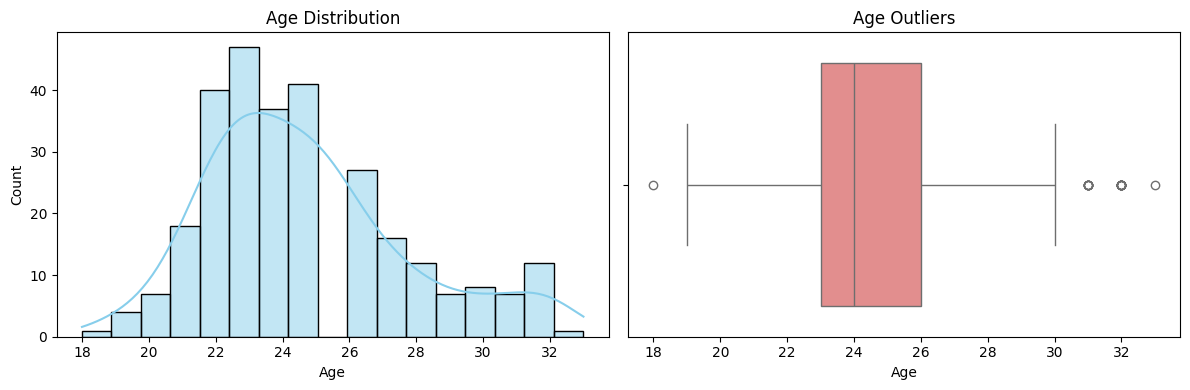

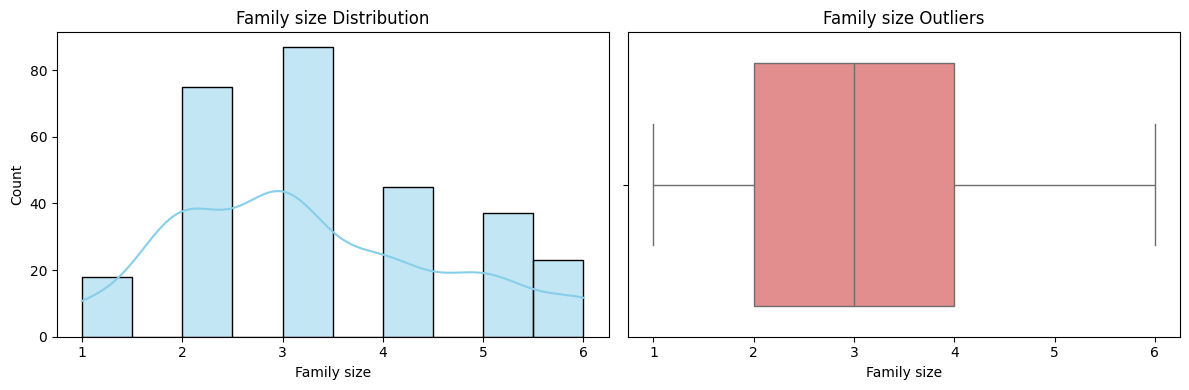

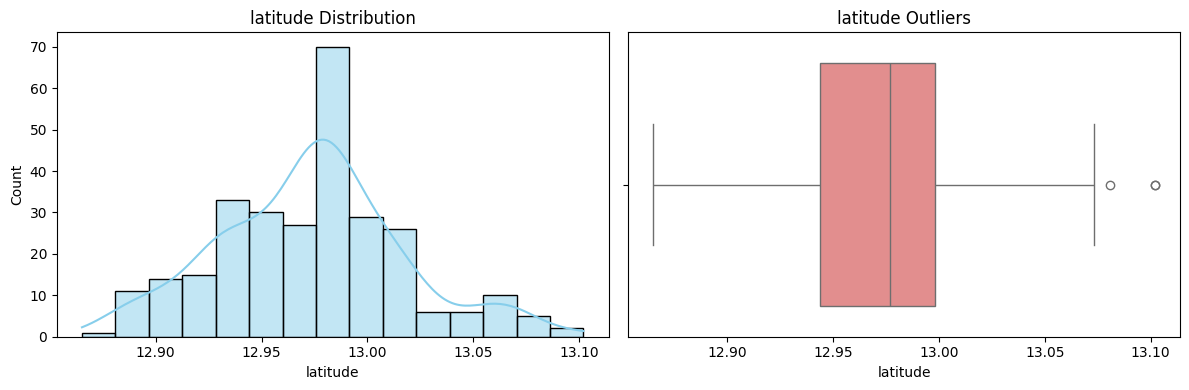

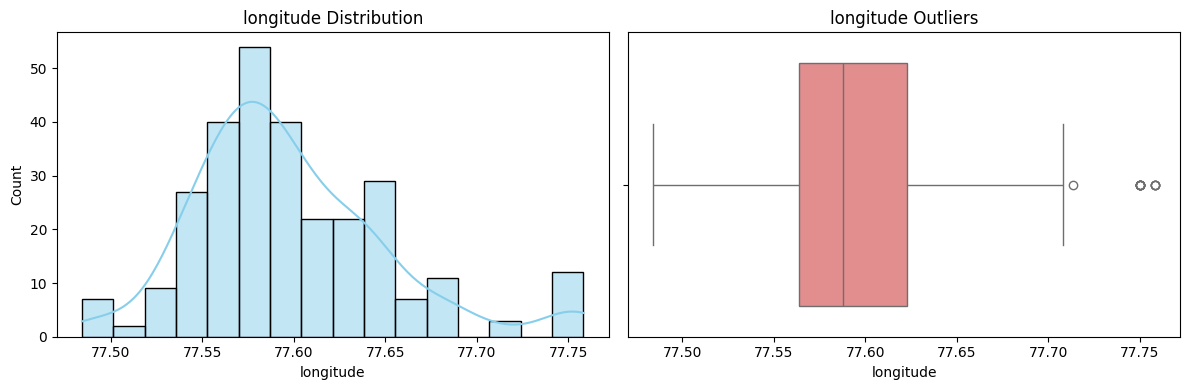

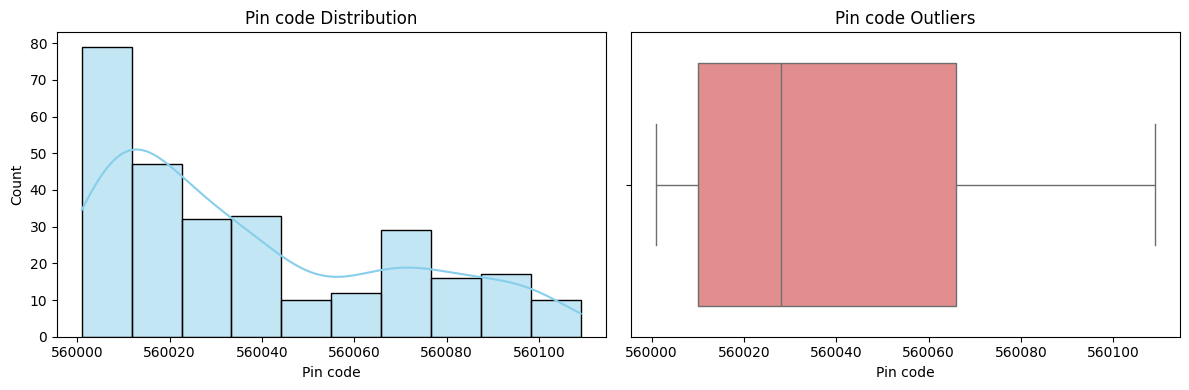

In [17]:
# Plot Histograms and Boxplots side-by-side for each numerical column
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram with KDE curve
    sns.histplot(data=df, x=col, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'{col} Distribution')
    
    # Boxplot for outliers
    sns.boxplot(data=df, x=col, ax=axes[1], color='lightcoral')
    axes[1].set_title(f'{col} Outliers')
    
    plt.tight_layout()
    plt.show()

### 3.1.2 Categorical Columns (Count plots)

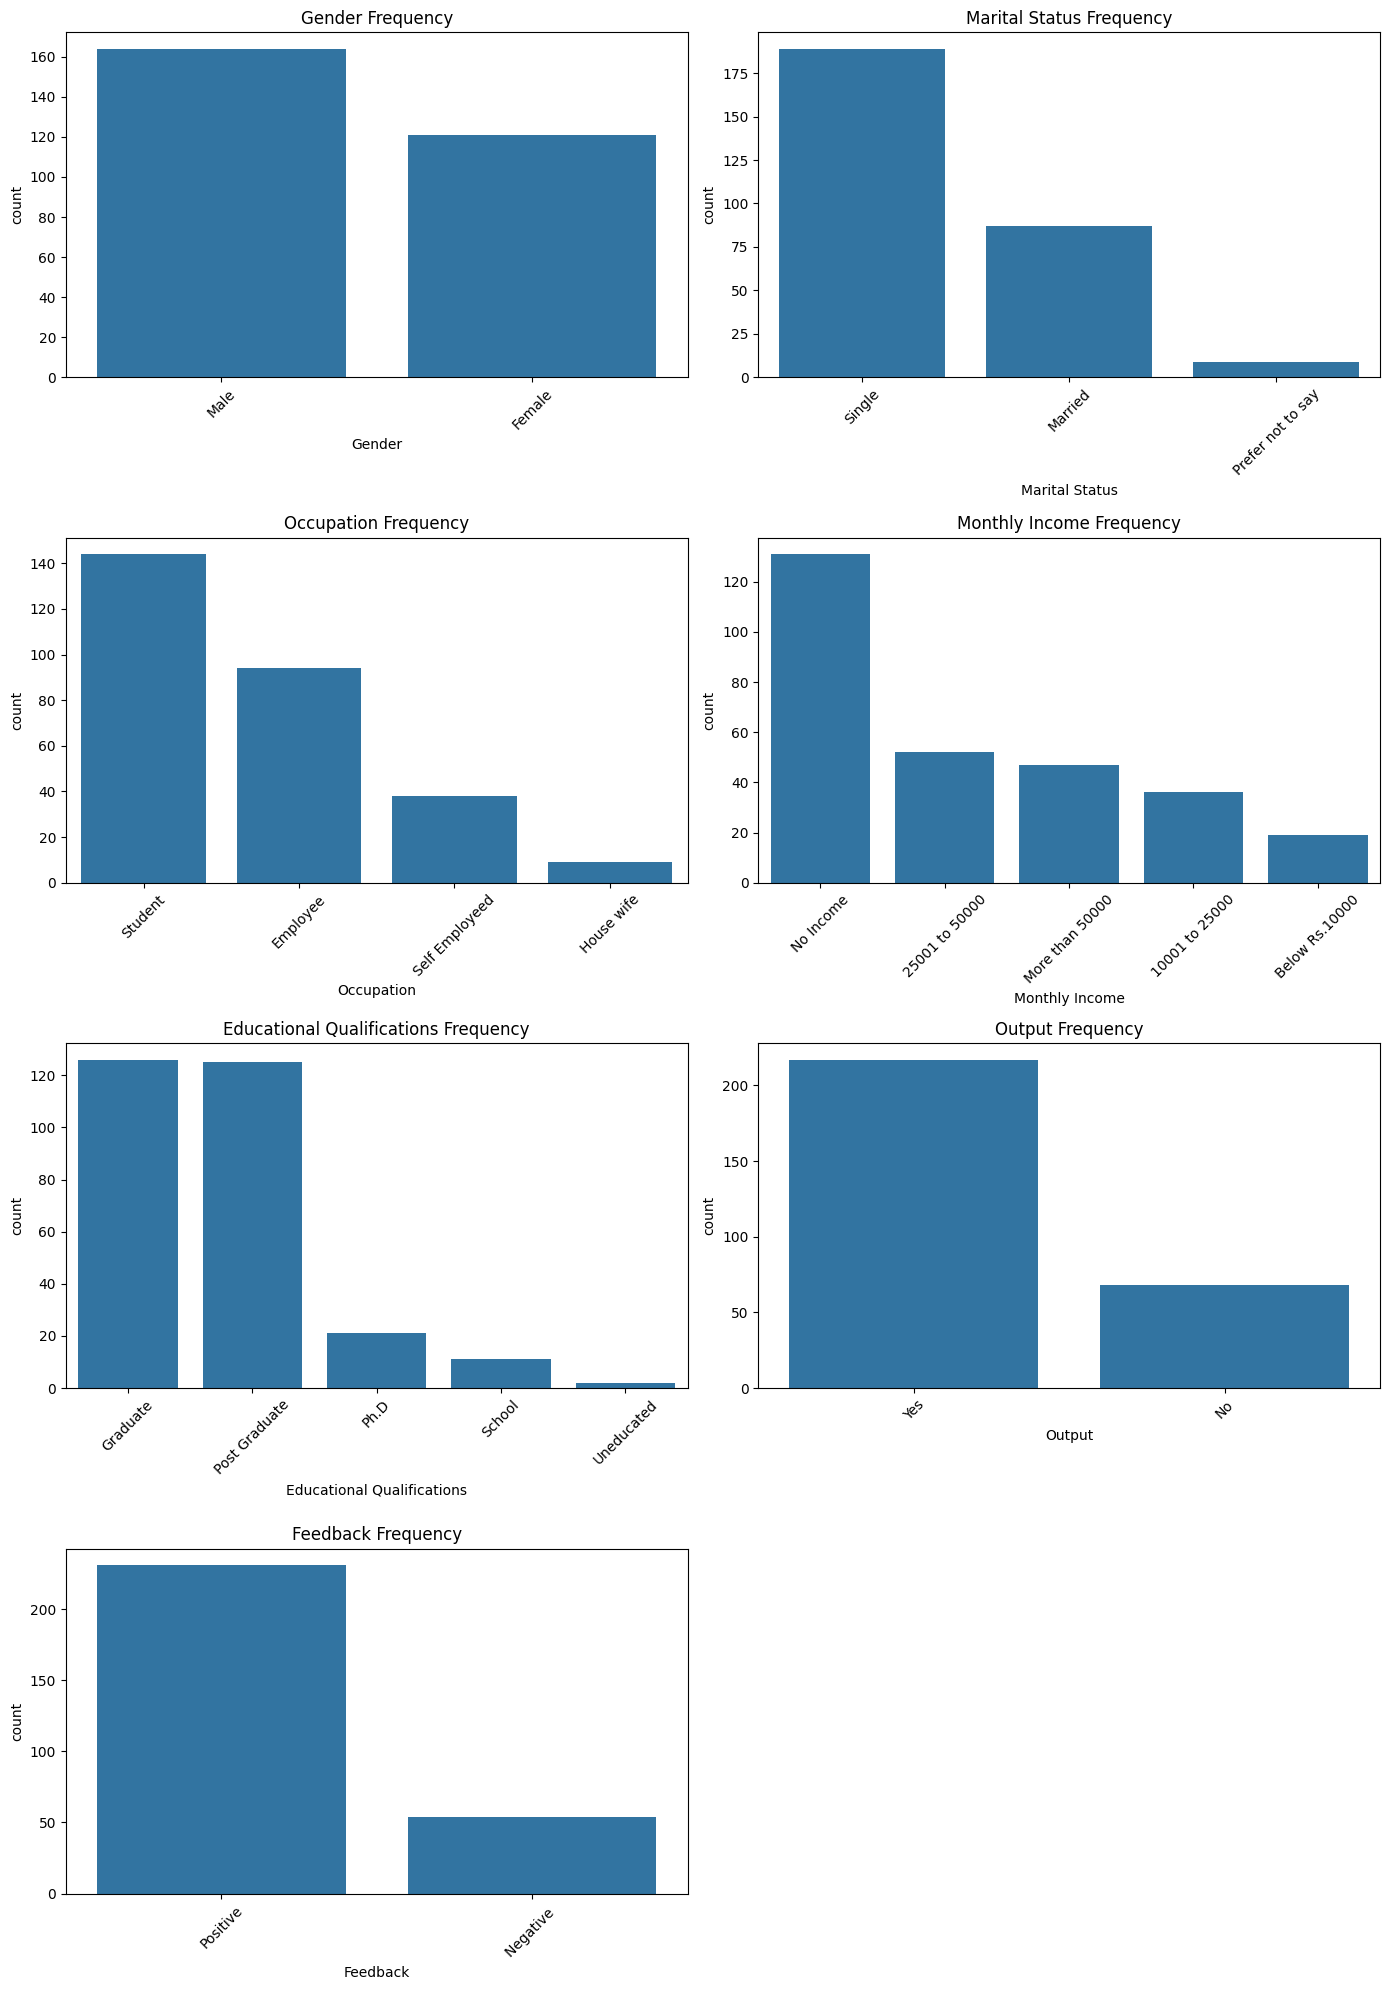

In [18]:
import math
n = len(cat_cols)
rows = math.ceil(n / 2)

plt.figure(figsize=(14, 5 * rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(rows, 2, i)

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index,
        legend=True
    )

    plt.title(f'{col} Frequency')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3.2 Bivariate Analysis

### 3.2.1 Numerical vs Numerical

**Heatmap**

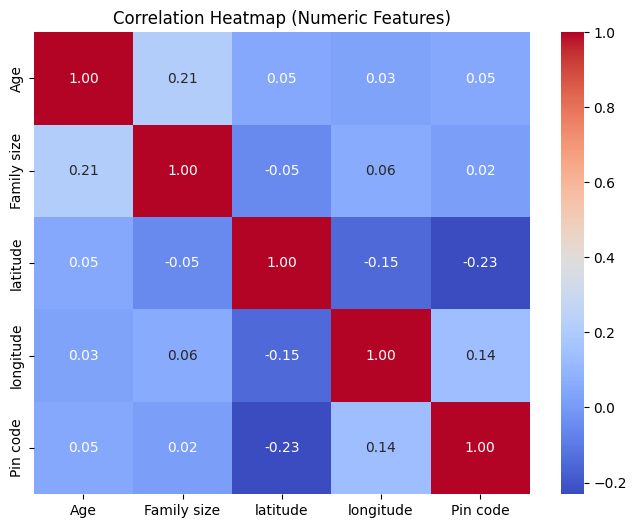

In [19]:
plt.figure(figsize=(8,6))
num_cols = df.select_dtypes(include=['int64','float64']).columns

corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

**Pairplot**

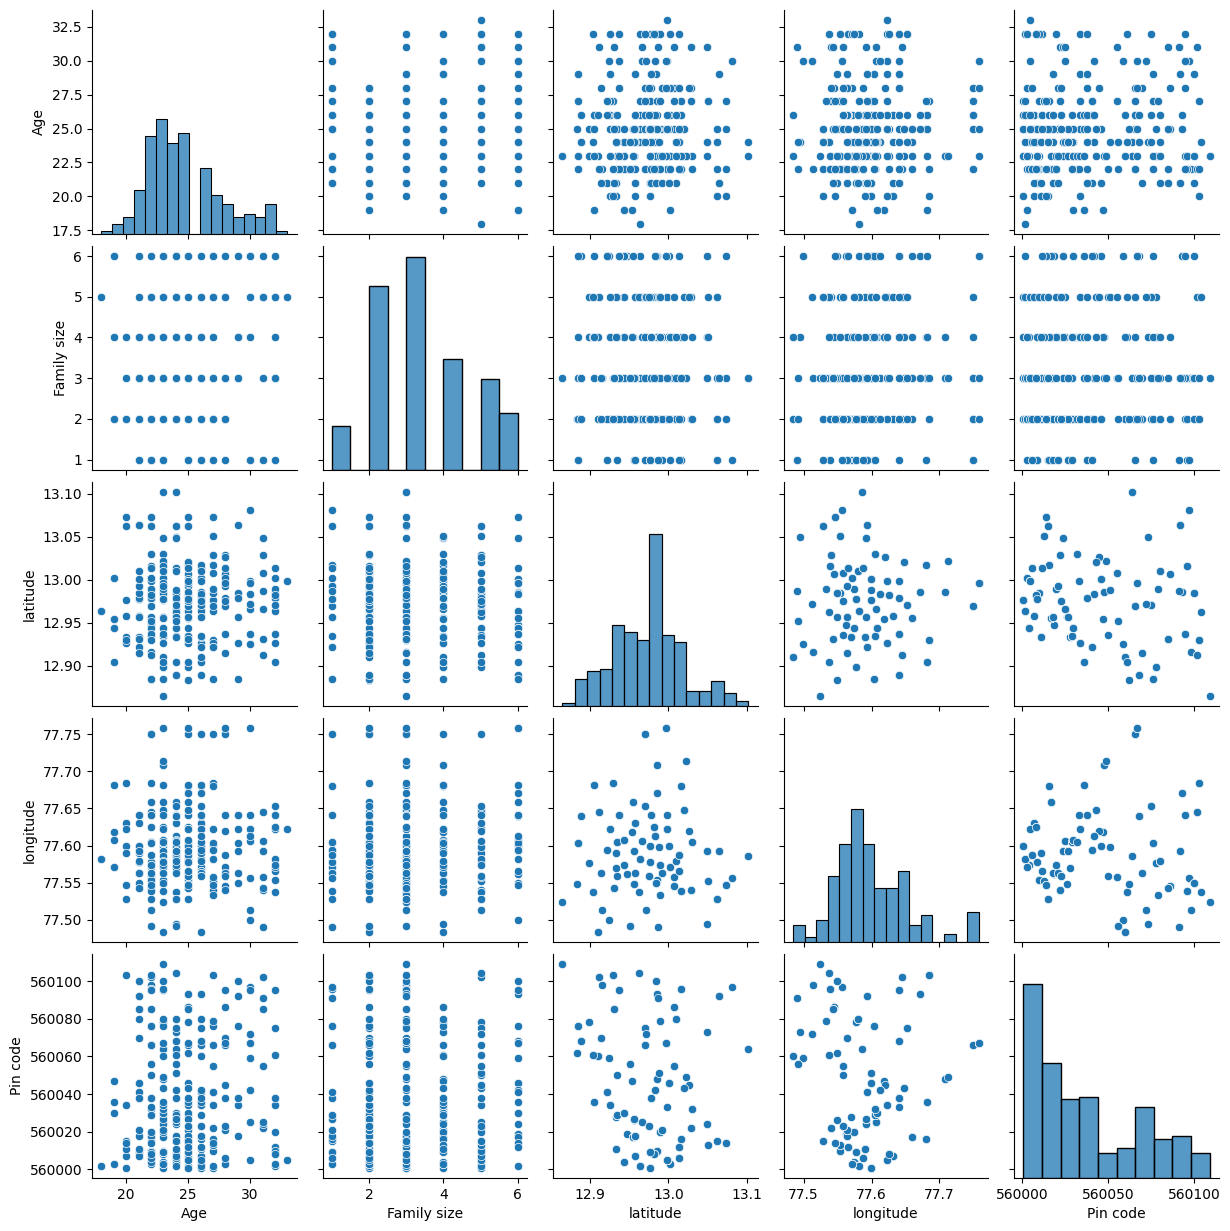

In [20]:
sns.pairplot(df[num_cols])
plt.show()

### 3.2.2 Categorical vs Categorical

**Count Plot**

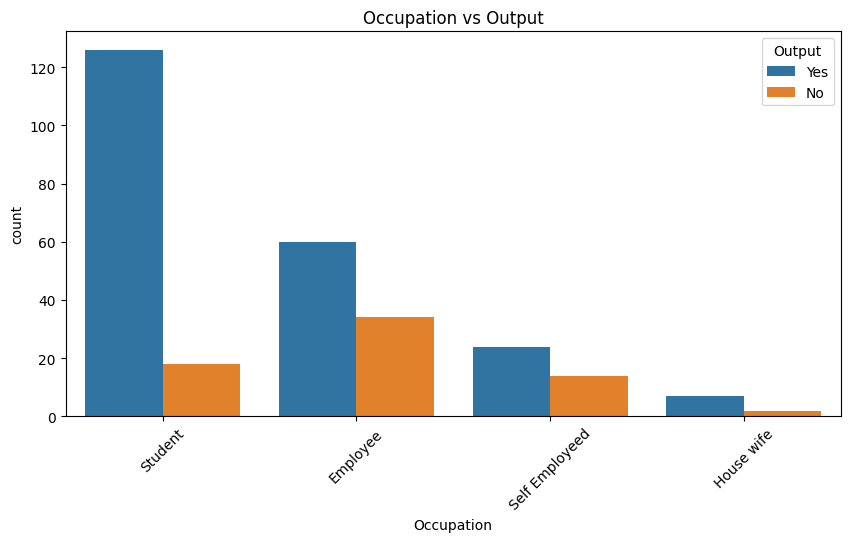

In [21]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Occupation', hue='Output')
plt.xticks(rotation=45)
plt.title("Occupation vs Output")
plt.show()

**Crosstab + Heatmap**

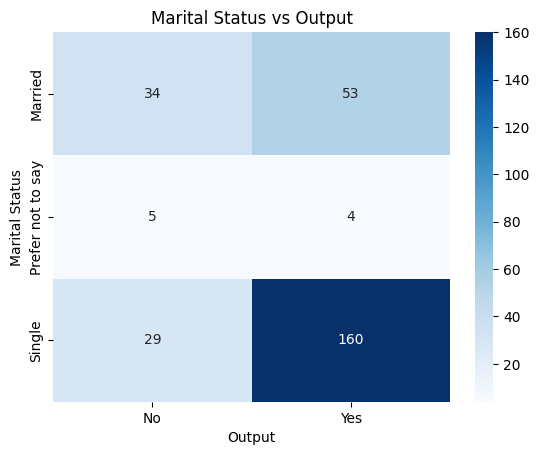

In [22]:
ct = pd.crosstab(df['Marital Status'], df['Output'])

sns.heatmap(ct, annot=True, cmap='Blues', fmt='d')
plt.title("Marital Status vs Output")
plt.show()

**Stacked Proportion Plot**

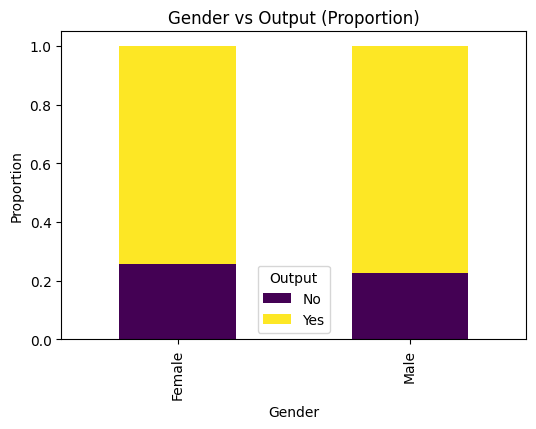

In [23]:
ct = pd.crosstab(df['Gender'], df['Output'], normalize='index')

ct.plot(kind='bar', stacked=True, figsize=(6,4), colormap='viridis')
plt.title("Gender vs Output (Proportion)")
plt.ylabel("Proportion")
plt.show()

### 3.3 Numerical vs Categorical

**Box Plot**

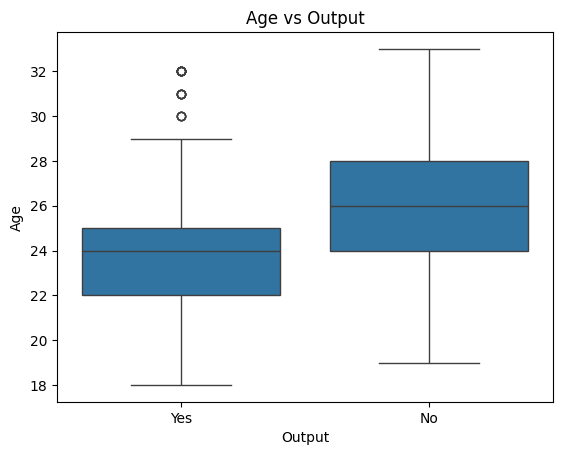

In [24]:
sns.boxplot(data=df, x='Output', y='Age')
plt.title("Age vs Output")
plt.show()

**Violin Plot (distribution insight)**

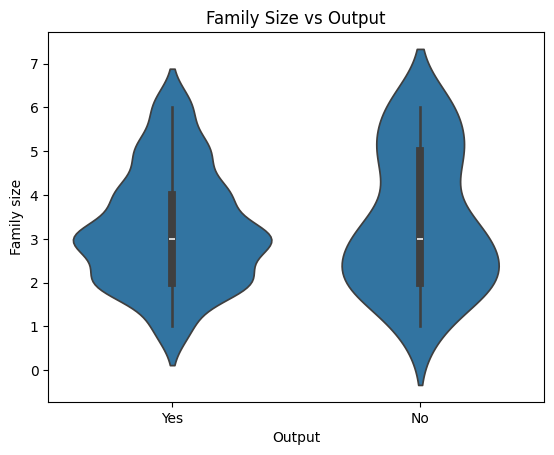

In [25]:
sns.violinplot(data=df, x='Output', y='Family size')
plt.title("Family Size vs Output")
plt.show()

## 3.3 Multivariate Analysis

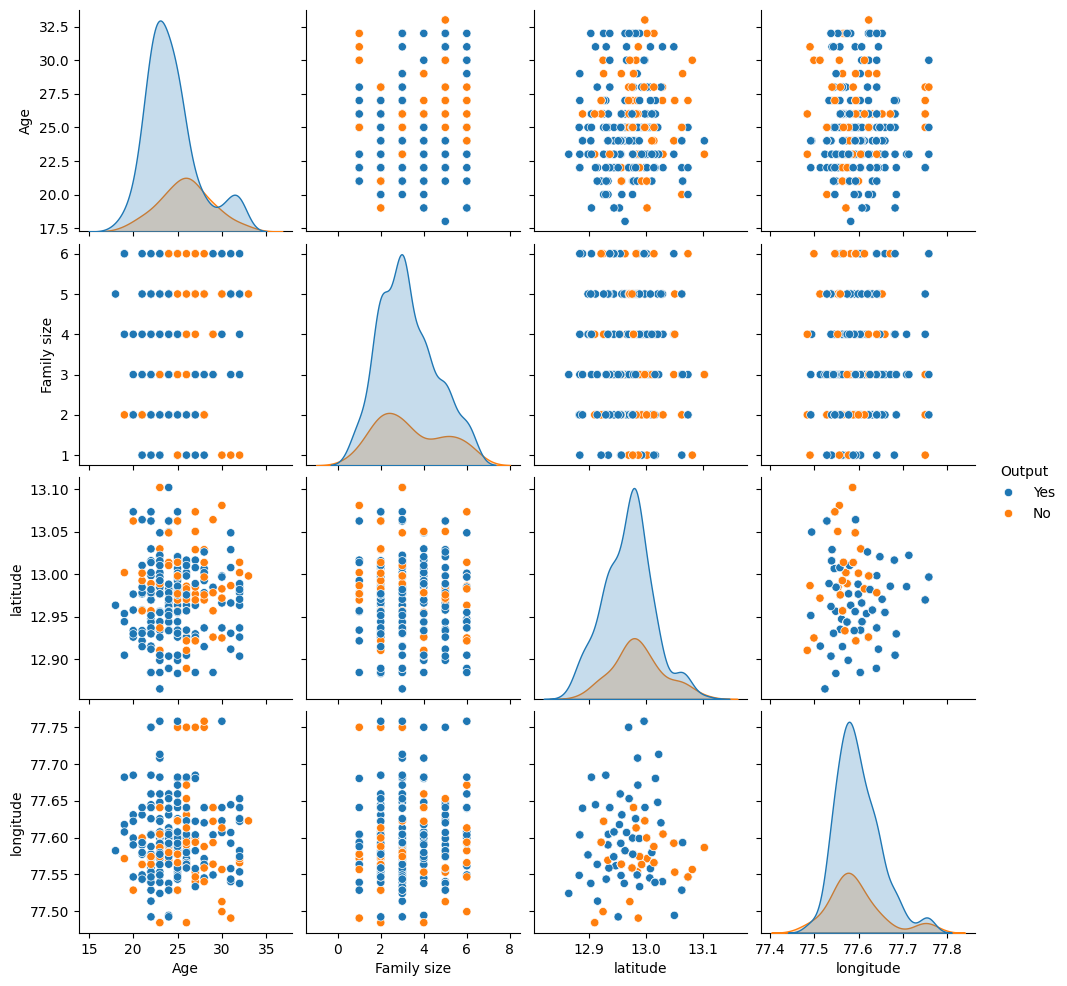

In [26]:
sns.pairplot(df, hue='Output', vars=['Age','Family size','latitude','longitude'])
plt.show()

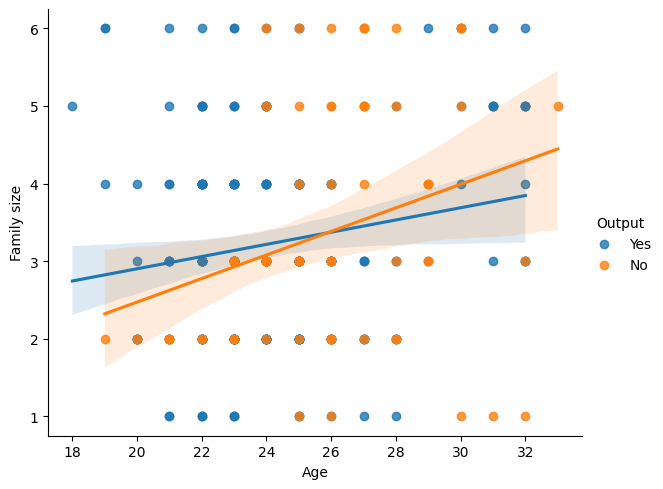

In [27]:
sns.lmplot(
    data=df,
    x='Age',
    y='Family size',
    hue='Output',
    height=5,
    aspect=1.2
)
plt.show()

# 4. Feature Transformation

In [28]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  OrdinalEncoder

## 4.1 Ordinal Encoding

In [29]:
income_order = [
    ["No Income",
     "Below Rs.10000",
     "10001 to 25000",
     "25001 to 50000",
     "More than 50000"]
]

income_encoder = OrdinalEncoder(categories=income_order)

df["Monthly Income"] = income_encoder.fit_transform(df[["Monthly Income"]])

## 4.2 One-Hot Encoding

In [30]:
df = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

Splitting Data before Feature scaling

In [31]:
X = df.drop('Output_Yes', axis=1)
y = df['Output_Yes']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## 4.3 Standard Scaling

In [33]:
# Implement StandardScaler to eliminate scaling bias across numerical features.

all_numeric_cols  = X_train.select_dtypes(include='number').columns # keep only non-binary numeric columns and scale them

cols_to_scale  = [c for c in all_numeric_cols  if df[c].nunique() > 2]

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Transform ONLY if using fit_transform so X_test uses it's own mean value
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [34]:
X_train = pd.DataFrame(X_train)
X_train.head(2)

,Age,Family size,latitude,longitude,Pin code,Gender_Male,Marital Status_Prefer not to say,Marital Status_Single,Occupation_House wife,Occupation_Self Employeed,Occupation_Student,Monthly Income_1.0,Monthly Income_2.0,Monthly Income_3.0,Monthly Income_4.0,Educational Qualifications_Ph.D,Educational Qualifications_Post Graduate,Educational Qualifications_School,Educational Qualifications_Uneducated,Feedback_Positive
293,0.089157,-1.677971,0.060609,-0.371040,-0.904392,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
25,0.089157,-0.217752,0.173213,0.552318,-0.937206,1,0,1,0,0,1,0,0,0,0,0,1,0,0,1


In [35]:
df.shape

(285, 21)

# 5. Machine Learning and Hyperparameter Tuning

In [36]:
# ------------------------
# Linear Model
# ------------------------
from sklearn.linear_model import LogisticRegression

# ------------------------
# KNN
# ------------------------
from sklearn.neighbors import KNeighborsClassifier

# ------------------------
# Tree-Based Models
# ------------------------
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ------------------------
# SVM
# ------------------------
from sklearn.svm import SVC

# ------------------------
# Boosting Models
# ------------------------
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ------------------------
# Metrics
# ------------------------
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [37]:
models = {

    # ============================
    # Linear Model
    # ============================
    "Logistic Regression": LogisticRegression(
        n_jobs=-1
    ),

    # ============================
    # KNN
    # ============================
    "KNN": KNeighborsClassifier(),

    # ============================
    # Tree-Based Models
    # ============================
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    # ============================
    # SVM
    # ============================
    "SVM": SVC(probability=True),

    # ============================
    # Boosting Models
    # ============================
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        tree_method='hist'
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        verbose=-1
    )
}

In [38]:
# Dictionary to store accuracy scores for comparison
accuracy_scores = {}

# Loop through each model
for name, model in models.items():
    # 1. Fit the model on the training data
    model.fit(X_train, y_train)
    
    # 2. Make predictions on the test data
    y_pred = model.predict(X_test)
    
    # 3. Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    accuracy_scores[name] = acc
    
    # 4. Print individual model performance
    print(f"=== {name} ===")
    print(f"Accuracy Score: {acc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

=== Logistic Regression ===
Accuracy Score: 0.8772

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.54      0.67        13
           1       0.88      0.98      0.92        44

    accuracy                           0.88        57
   macro avg       0.88      0.76      0.80        57
weighted avg       0.88      0.88      0.87        57

--------------------------------------------------
=== KNN ===
Accuracy Score: 0.7719

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.15      0.24        13
           1       0.79      0.95      0.87        44

    accuracy                           0.77        57
   macro avg       0.65      0.55      0.55        57
weighted avg       0.73      0.77      0.72        57

--------------------------------------------------
=== Decision Tree ===
Accuracy Score: 0.7719

Classification Report:
              precision    recall  f1-sco

In [39]:
# Convert scores to a DataFrame for clean visualization
df_comparison = pd.DataFrame(list(accuracy_scores.items()), columns=['Model', 'Accuracy'])
df_comparison = df_comparison.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("🏆 Model Comparison Leaderboard 🏆")
print(df_comparison)

🏆 Model Comparison Leaderboard 🏆
                 Model  Accuracy
0  Logistic Regression  0.877193
1              XGBoost  0.859649
2             LightGBM  0.859649
3        Random Forest  0.824561
4                  SVM  0.807018
5        Decision Tree  0.771930
6                  KNN  0.771930


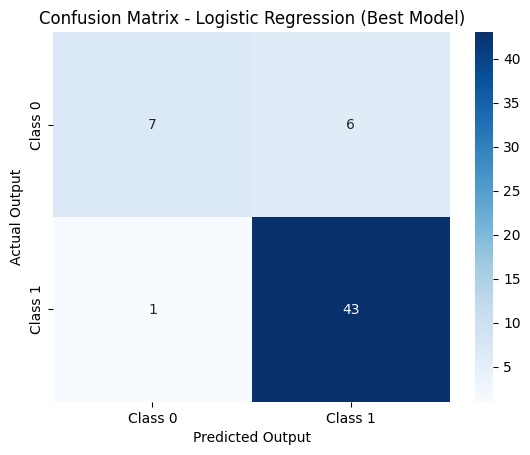

In [40]:
# 1. Get best model name from comparison dataframe
best_model_name = df_comparison.iloc[0]['Model']
best_model = models[best_model_name]

# 2. Predict using best model
y_pred_best = best_model.predict(X_test)

# 3. Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# 4. Plot heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Class 0', 'Class 1'],
    yticklabels=['Class 0', 'Class 1']
)

plt.title(f'Confusion Matrix - {best_model_name} (Best Model)')
plt.xlabel('Predicted Output')
plt.ylabel('Actual Output')
plt.show()

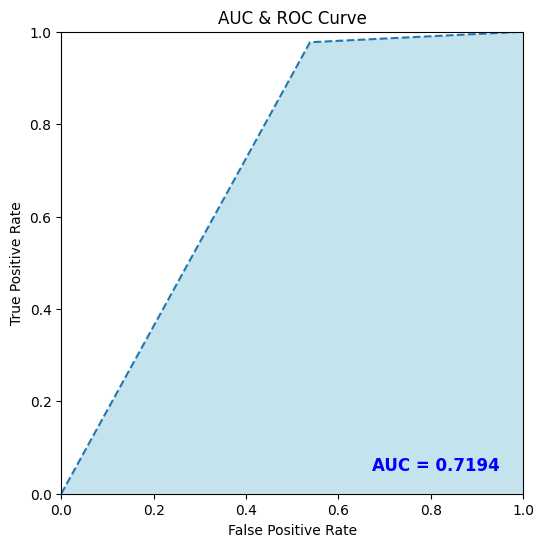

In [41]:
from sklearn import metrics
auc = metrics.roc_auc_score(y_test, y_pred)

false_positive_rate, true_positive_rate, thresolds = metrics.roc_curve(y_test, y_pred)

plt.figure(figsize=(6, 6), dpi=100)
plt.axis('scaled')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.title("AUC & ROC Curve")
plt.plot(false_positive_rate, true_positive_rate,'--' )
plt.fill_between(false_positive_rate, true_positive_rate, facecolor='lightblue', alpha=0.7)
plt.text(0.95, 0.05, 'AUC = %0.4f' % auc, ha='right', fontsize=12, weight='bold', color='blue')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()